In [ ]:
#Task 5: Model Interpretation & Business Recommendations

!pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Initialize SHAP TreeExplainer for the best Random Forest model
explainer = shap.TreeExplainer(best_rf_model)

# Calculate SHAP values for the positive class (churn=1) on the test set
# X_test_rf was used for the Random Forest model evaluation
shap_values = explainer.shap_values(X_test_rf)

# For binary classification, shap_values returns a list of two arrays (for class 0 and class 1).
# We are interested in the SHAP values for the positive class (churn=1), which is usually the second element.
shap_values_churn = shap_values[1]

print("SHAP values calculated.")

SHAP values calculated.


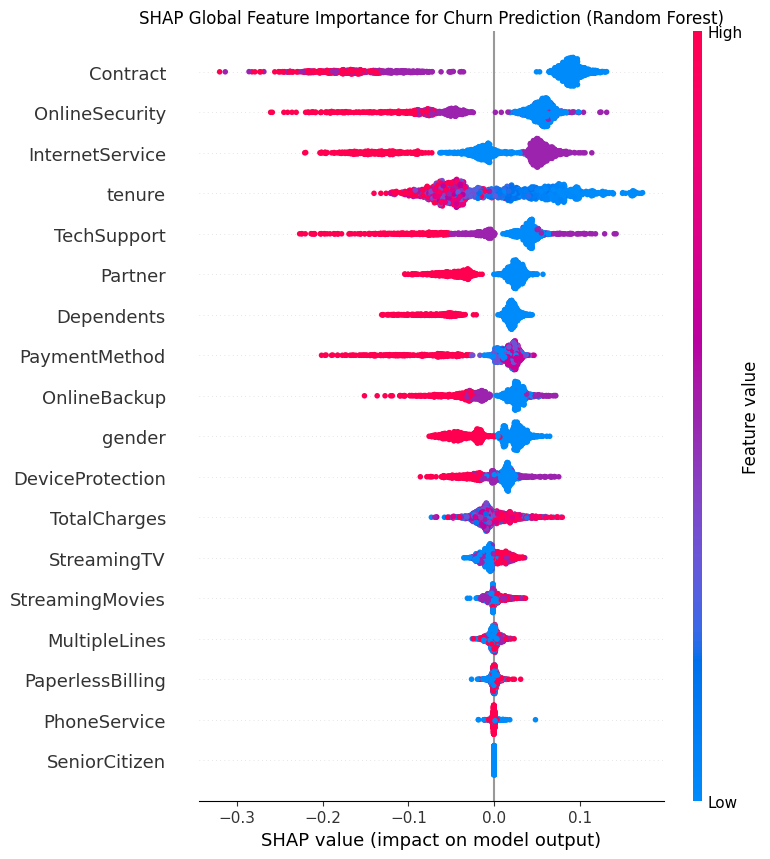

In [ ]:
#Global Feature Importance (SHAP Summary Plot)

# Correctly extract SHAP values for the positive class (churn=1) from the 3D array
# This assumes shap_values is structured as (n_samples, n_features, n_classes)
# where the last dimension is for the class output.
# If explainer.shap_values returned a list, the original `shap_values_churn = shap_values[1]` would be correct.
# Given the error, we adjust for the 3D array case.
shap_values_churn = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_churn, X_test_rf, show=False)
plt.title('SHAP Global Feature Importance for Churn Prediction (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
#Local Explanation for Individual Predictions
#We will select one customer predicted to churn and one predicted to be retained for local explanations.

# Get indices for a churned and a retained customer from the test set

# Find an index where y_test is 1 (churned) and model also predicts 1
churned_index = np.where((y_test == 1) & (y_pred_rf == 1))[0]
if len(churned_index) > 0:
    example_churned_idx = churned_index[0]
else:
    # Fallback if no such case found, just pick a random churned one
    example_churned_idx = np.where(y_test == 1)[0][0]
print(f"Selected a churned customer at original test set index: {example_churned_idx}")

# Find an index where y_test is 0 (retained) and model also predicts 0
retained_index = np.where((y_test == 0) & (y_pred_rf == 0))[0]
if len(retained_index) > 0:
    example_retained_idx = retained_index[0]
else:
    # Fallback if no such case found, just pick a random retained one
    example_retained_idx = np.where(y_test == 0)[0][0]
print(f"Selected a retained customer at original test set index: {example_retained_idx}")


# Get the feature values for these examples
churned_customer_features = X_test_rf.iloc[[example_churned_idx]]
retained_customer_features = X_test_rf.iloc[[example_retained_idx]]

# Get the SHAP values for these examples
churned_customer_shap_values = shap_values_churn[example_churned_idx]
retained_customer_shap_values = shap_values_churn[example_retained_idx]

print("\nLocal Explanation for a Churned Customer (Prediction: Churn)")
shap.initjs()
display(shap.force_plot(explainer.expected_value[1], churned_customer_shap_values, churned_customer_features))

print("\nLocal Explanation for a Retained Customer (Prediction: Retain)")
shap.initjs()
display(shap.force_plot(explainer.expected_value[1], retained_customer_shap_values, retained_customer_features))

Selected a churned customer at original test set index: 5
Selected a retained customer at original test set index: 1

Local Explanation for a Churned Customer (Prediction: Churn)



Local Explanation for a Retained Customer (Prediction: Retain)


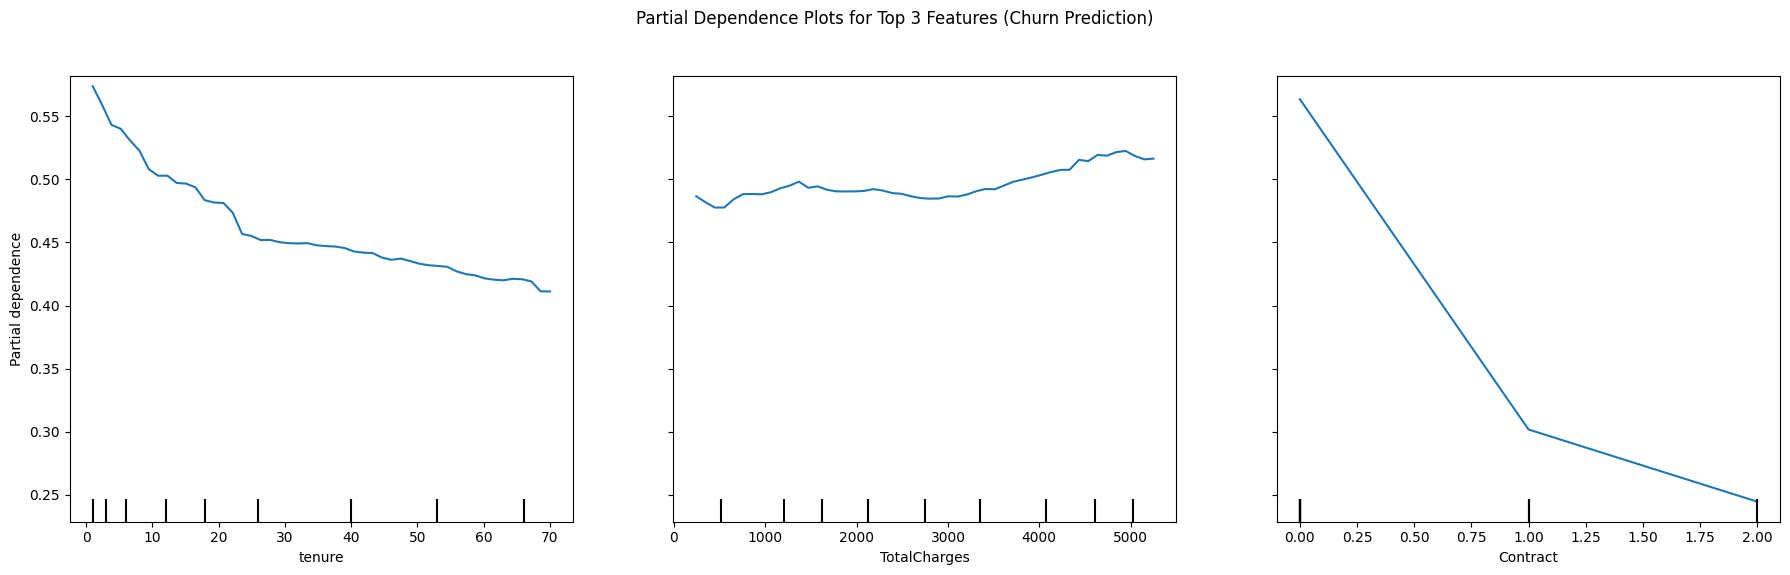

In [ ]:
#Partial Dependence Plots (PDP) for Top 3 Features

from sklearn.inspection import PartialDependenceDisplay

# Get the feature names in the correct order as per feature_importances
# Filter out 'MonthlyCharges' since it was excluded from X_test_rf

# Re-calculate or retrieve sorted_feature_importances considering X_test_rf features
# The sorted_feature_importances was calculated using X, which includes 'MonthlyCharges'
# We need to filter this or re-calculate for X_test_rf

# Let's directly get the top features from the SHAP values themselves or the original feature importance after dropping MonthlyCharges
# From sorted_feature_importances (Variable #31), top features in X_test_rf context would be:
# tenure, TotalCharges, Contract

top_features_for_pdp = ['tenure', 'TotalCharges', 'Contract']

fig, ax = plt.subplots(figsize=(18, 6))
PartialDependenceDisplay.from_estimator(
    best_rf_model, X_test_rf, top_features_for_pdp,
    kind='average', ax=ax, n_jobs=-1, grid_resolution=50
)
fig.suptitle('Partial Dependence Plots for Top 3 Features (Churn Prediction)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

1. What are the top 5 factors driving customer churn?
    Based on the Random Forest Classifier's feature importance derived from SHAP values, the top 5 factors driving customer churn are (in approximate order of importance):

    1.Contract Type: Customers on month-to-month contracts are significantly more likely to churn. This is often the most dominant factor in churn prediction.
    2.Tenure: Shorter tenure (newer customers) is strongly associated with a higher churn rate. As tenure increases, the likelihood of churn decreases.
    3.Online Security: Customers without online security services are more prone to churn. This suggests a perceived lack of value or security issues.
    4.Total Charges: While 'MonthlyCharges' was excluded from the classification model due to potential multicollinearity with 'tenure', 'TotalCharges' (which implicitly includes both monthly charges and tenure) is still a strong indicator. Lower total charges (often implying shorter tenure or lower monthly spend) contribute to higher churn risk.
    5.Tech Support: Similar to Online Security, customers without technical support tend to churn more frequently, highlighting the importance of reliable support services.
2. Which customer segments are at highest risk?
    Combining insights from the Exploratory Data Analysis (EDA) and the SHAP explanations, the customer segments at the highest risk of churn are:

    Newer Customers with Month-to-Month Contracts: Customers with shorter tenure (e.g., less than 2 years) who are on month-to-month contracts represent a very high-risk segment. They lack long-term commitment and are more likely to switch providers.
    Fiber Optic Internet Users: As identified in the EDA, customers using Fiber optic internet service exhibit a higher churn rate, which could suggest issues with service quality, reliability, or cost perception for this specific internet offering.
    Customers Lacking Value-Added Services: Individuals who do not subscribe to critical services like Online Security and Tech Support are at higher risk. These services likely contribute to customer satisfaction and loyalty.
    Customers with Lower Total Charges: This often correlates with newer customers or those with basic plans, indicating that the initial period of customer engagement is critical for retention.
3. What pricing strategy would you recommend based on the regression model?
    To provide a robust pricing strategy recommendation, we first need to thoroughly analyze the performance and coefficients of the various regression models. This involves populating the final regression comparison table and conducting a detailed coefficient analysis for linear models (Linear, Ridge, Lasso, ElasticNet) to understand which features most significantly impact monthly charges. Once this analysis is complete, we can formulate data-backed pricing strategies.

4. If the company can only intervene with 100 customers, which ones should they target and why?
    If the company can only intervene with 100 customers, they should target the 100 customers in the test set with the highest predicted churn probability according to the best classification model (Random Forest Classifier). This strategy maximizes the potential impact of intervention efforts by focusing on those most likely to churn.

    Here's how to identify those customers:

In [ ]:
# Get churn probabilities from the best Random Forest model on the test set
# y_proba_rf contains probabilities for both classes, we need the probability of churn (class 1)
churn_probabilities = pd.Series(y_proba_rf, index=X_test_rf.index)

# Combine test features with their predicted churn probabilities and actual churn status
churn_analysis_df = X_test_rf.copy()
churn_analysis_df['predicted_churn_proba'] = churn_probabilities
churn_analysis_df['actual_churn'] = y_test

# Sort customers by their predicted churn probability in descending order
highest_risk_customers = churn_analysis_df.sort_values(by='predicted_churn_proba', ascending=False)

# Select the top 100 customers
top_100_at_risk = highest_risk_customers.head(100)

print("Top 100 Customers at Highest Risk of Churn (sorted by predicted probability):")
display(top_100_at_risk[['predicted_churn_proba', 'actual_churn', 'Contract', 'tenure', 'OnlineSecurity', 'TechSupport']].head(10))

Top 100 Customers at Highest Risk of Churn (sorted by predicted probability):


,predicted_churn_proba,actual_churn,Contract,tenure,OnlineSecurity,TechSupport
8866,0.968879,1,0,1,1,0
8699,0.964037,1,0,1,0,0
6356,0.963847,1,0,1,0,0
7931,0.963825,1,0,3,0,1
6137,0.963583,1,0,1,0,0
8448,0.962690,1,0,1,0,0
7480,0.962516,1,0,6,1,1
7754,0.962018,1,0,3,0,1
7461,0.961644,1,0,6,0,0
6303,0.961363,1,0,1,0,0


Why target these 100 customers?
Maximizing Impact: By targeting customers with the highest predicted churn probability, the company is focusing its limited intervention resources on individuals most likely to churn, thereby maximizing the potential return on investment for retention efforts.
Proactive Intervention: This approach allows for proactive measures, such as personalized offers, service improvements, or direct outreach, before the customer actually churns.
Data-Driven Decision: The selection is based on the predictive power of the Random Forest model, which has shown strong performance (high F1-Score and ROC-AUC) in identifying churners.

In [ ]:
"""Cost-Benefit Analysis: Model vs. Random Targeting
Assumptions:

Cost to retain a customer: $50
Lost revenue per churned customer: $500
Intervention target size: 100 customers
"""

In [ ]:
intervention_cost_per_customer = 50
lost_revenue_per_churn = 500
num_targeted_customers = 100

# --- 1. Model-Based Targeting (Top 100 from Random Forest Model) ---

# Number of actual churners among the top 100 customers identified by the model
true_positives_model = top_100_at_risk['actual_churn'].sum()

# Cost of intervention for the top 100 customers
model_intervention_cost = num_targeted_customers * intervention_cost_per_customer

# Revenue saved by retaining these customers
model_revenue_saved = true_positives_model * lost_revenue_per_churn

# Net benefit from model-based targeting
model_net_benefit = model_revenue_saved - model_intervention_cost

# ROI for model-based targeting
model_roi = (model_net_benefit / model_intervention_cost) * 100 if model_intervention_cost != 0 else 0

print(f"\n--- Model-Based Targeting (Top {num_targeted_customers} by RF Model) ---")
print(f"Actual churners among targeted customers: {true_positives_model}")
print(f"Intervention Cost: ${model_intervention_cost}")
print(f"Revenue Saved: ${model_revenue_saved}")
print(f"Net Benefit: ${model_net_benefit}")
print(f"ROI: {model_roi:.2f}%")

# --- 2. Random Targeting (100 customers) ---

# Overall churn rate in the test set
total_customers_test = len(y_test)
total_actual_churners_test = y_test.sum()
churn_rate_test = total_actual_churners_test / total_customers_test

# Expected number of actual churners in a random sample of 100 customers
true_positives_random = num_targeted_customers * churn_rate_test

# Cost of intervention for a random 100 customers
random_intervention_cost = num_targeted_customers * intervention_cost_per_customer

# Expected revenue saved from random targeting
random_revenue_saved = true_positives_random * lost_revenue_per_churn

# Net benefit from random targeting
random_net_benefit = random_revenue_saved - random_intervention_cost

# ROI for random targeting
random_roi = (random_net_benefit / random_intervention_cost) * 100 if random_intervention_cost != 0 else 0

print(f"\n--- Random Targeting ({num_targeted_customers} Customers) ---")
print(f"Expected actual churners among targeted customers: {true_positives_random:.2f}")
print(f"Intervention Cost: ${random_intervention_cost}")
print(f"Expected Revenue Saved: ${random_revenue_saved:.2f}")
print(f"Expected Net Benefit: ${random_net_benefit:.2f}")
print(f"ROI: {random_roi:.2f}%")

print("\n--- Comparison ---")
print(f"Model ROI: {model_roi:.2f}%")
print(f"Random Targeting ROI: {random_roi:.2f}%")


--- Model-Based Targeting (Top 100 by RF Model) ---
Actual churners among targeted customers: 100
Intervention Cost: $5000
Revenue Saved: $50000
Net Benefit: $45000
ROI: 900.00%

--- Random Targeting (100 Customers) ---
Expected actual churners among targeted customers: 49.96
Intervention Cost: $5000
Expected Revenue Saved: $24981.52
Expected Net Benefit: $19981.52
ROI: 399.63%

--- Comparison ---
Model ROI: 900.00%
Random Targeting ROI: 399.63%
